In [13]:
import os, sys, importlib, pathlib
import pandas as pd
from pathlib import Path
sys.path.append (os.path.abspath(".."))

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import statsmodels.api as sm
import statsmodels.formula.api as smf
# my utils
from utils import desc_new_old

tactics_bio = [
    "ouverture",
    "authenticité",
    "sociabilité",
    "auto_promotion",
    "exemplarité",
]

tactics_pic=['host_picture_type']# no_person, pro_style, life_style



In [14]:
path_df=r"../data_processed\listings_tactics_bio_vis-paris_london-2306_2312_2406.csv"
df_all=pd.read_csv(path_df)
print(df_all.shape)

C:\Users\yeliu\AppData\Local\Temp\ipykernel_19064\4181052062.py:2: DtypeWarning: Columns (6,68,115) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all=pd.read_csv(path_df)


(266852, 125)


In [15]:
tactics_bio=["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]
tactic_pic=["host_picture_type"]# is_smiling
# vars_person=['age_class','gender']


df_all[tactics_bio]=df_all[tactics_bio].fillna(0)
df_all["host_picture_type"]=df_all["host_picture_type"].fillna("no_person")

print(df_all[tactics_bio].isna().value_counts())
print(df_all["host_picture_type"].isna().value_counts())

df_all['time']=df_all['time'].astype(str)
print(df_all.time.dtype)
print(df_all[['time','in_paris']].value_counts(dropna=False))


ouverture  authenticité  sociabilité  auto_promotion  exemplarité
False      False         False        False           False          266852
Name: count, dtype: int64
host_picture_type
False    266852
Name: count, dtype: int64
object
time  in_paris
2406  1           62738
      0           49856
2312  0           43172
2306  0           42356
2312  1           35829
2306  1           32901
Name: count, dtype: int64


## new & old

In [16]:
# df = df_all.copy()
host_2306 = df_all[df_all['time'] == "2306"]['host_id'].to_list()
host_2312 = df_all[df_all['time'] == "2312"]['host_id'].to_list()

# sub_df = df[df['time'] != '2306'].copy()

df_all['is_new_host'] = 0  # 先初始化

# 先选中mask避免覆盖
# 2312 vs 2306
mask_2312 = df_all['time'] == "2312"
df_all.loc[mask_2312, 'is_new_host'] = (
    ~df_all.loc[mask_2312, 'host_id'].isin(host_2306)
).astype(int)

# 2406 vs 2312
mask_2406 = df_all['time'] == "2406"
df_all.loc[mask_2406, 'is_new_host'] = (
    ~df_all.loc[mask_2406, 'host_id'].isin(host_2312)
).astype(int)

In [17]:
# 新老房东数量统计

df=df_all.copy()

df_2406=df[df['time']=="2406"]
print(df_2406.shape)
print(df_2406[['time', "in_paris",'is_new_host']].value_counts())


df_2312=df[df['time']=="2312"]
print(df_2312.shape)
print(df_2312[['time',"in_paris",'is_new_host']].value_counts())
print(df_2312['time'].dtype)

(112594, 126)
time  in_paris  is_new_host
2406  0         0              37937
      1         0              34176
                1              28562
      0         1              11919
Name: count, dtype: int64
(79001, 126)
time  in_paris  is_new_host
2312  0         0              32360
      1         0              24780
                1              11049
      0         1              10812
Name: count, dtype: int64
object


In [29]:
df_all.columns.to_list()

['id',
 'listing_url',
 'scrape_id',
 'last_scraped',
 'source',
 'name',
 'description',
 'neighborhood_overview',
 'picture_url',
 'host_id',
 'host_url',
 'host_name',
 'host_since',
 'host_location',
 'host_about',
 'host_response_time',
 'host_response_rate',
 'host_acceptance_rate',
 'host_is_superhost',
 'host_thumbnail_url',
 'host_picture_url',
 'host_neighbourhood',
 'host_listings_count',
 'host_total_listings_count',
 'host_verifications',
 'host_has_profile_pic',
 'host_identity_verified',
 'neighbourhood',
 'neighbourhood_cleansed',
 'neighbourhood_group_cleansed',
 'latitude',
 'longitude',
 'property_type',
 'room_type',
 'accommodates',
 'bathrooms',
 'bathrooms_text',
 'bedrooms',
 'beds',
 'amenities',
 'price',
 'minimum_nights',
 'maximum_nights',
 'minimum_minimum_nights',
 'maximum_minimum_nights',
 'minimum_maximum_nights',
 'maximum_maximum_nights',
 'minimum_nights_avg_ntm',
 'maximum_nights_avg_ntm',
 'calendar_updated',
 'has_availability',
 'availability_30

has_no_review_nextQ
0    157845
1    109007
Name: count, dtype: int64


,in_paris,time,has_no_review_nextQ,proportion
1,0,2306,1,0.343328
3,0,2312,1,0.464838
5,0,2406,1,0.388238
7,1,2306,1,0.288502
9,1,2312,1,0.457758
11,1,2406,1,0.464599


<Axes: xlabel='time', ylabel='proportion'>

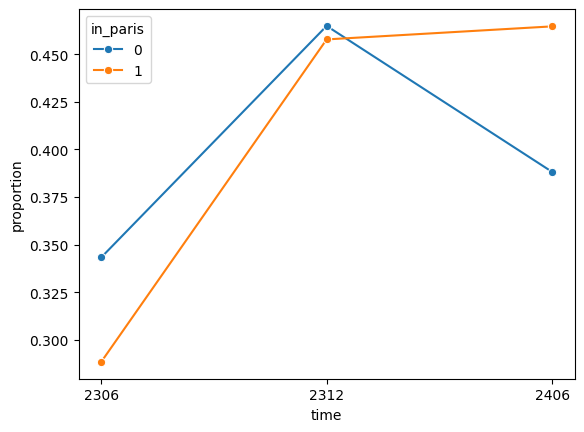

In [ ]:
# print(df_all['number_of_reviews_nextQ'].value_counts(dropna=False))
df_all['has_no_review_nextQ']=df_all["number_of_reviews_nextQ"].apply(lambda x : 1 if x==0 else 0)
print(df_all['has_no_review_nextQ'].value_counts(dropna=False))
agg_no_reviews=df_all.groupby(["in_paris","time"])["has_no_review_nextQ"].value_counts(normalize=True).reset_index().sort_values(['has_no_review_nextQ',"in_paris","time"])

# paris在jo期间没有更多无预定，在2312已经有45%了,但对比london可知，本应该下降？

agg_plot=agg_no_reviews[agg_no_reviews['has_no_review_nextQ']==1]
display(agg_plot)
sns.lineplot(
    data=agg_plot,
    x='time',
    y='proportion',
    hue='in_paris',
    marker="o"
)

In [18]:
display(df_2406.groupby(["is_new_host","in_paris"])[['booking_rate_l90d','years_since_host',"price","availability_90","number_of_reviews_ltm","review_scores_rating"]].mean().reset_index())
display(df_2406.groupby(["is_new_host","in_paris"])['host_is_superhost'].value_counts(normalize=True))
display(df_2406.groupby(['is_new_host', "in_paris"])['host_picture_type'].value_counts(normalize=True).reset_index())
# paris 2024显然更高比例的portrait
# 新房东反而价格更高！

,is_new_host,in_paris,booking_rate_l90d,years_since_host,price,availability_90,number_of_reviews_ltm,review_scores_rating
0,0,0,0.113584,6.708754,223.874792,50.852229,9.598519,4.716362
1,0,1,0.085889,7.061330,269.064314,52.301820,10.363062,4.743160
2,1,0,0.138104,5.397936,170.112258,48.431580,5.489638,4.792441
3,1,1,0.064405,6.567747,300.471571,47.077130,3.704643,4.819227


is_new_host  in_paris  host_is_superhost
0            0         f                    0.709492
                       t                    0.290508
             1         f                    0.723929
                       t                    0.276071
1            0         f                    0.848813
                       t                    0.151187
             1         f                    0.900287
                       t                    0.099713
Name: proportion, dtype: float64

,is_new_host,in_paris,host_picture_type,proportion
0,0,0,no_person,0.383900
1,0,0,pro_style,0.322060
2,0,0,life_style,0.294040
3,0,1,no_person,0.380794
4,0,1,pro_style,0.347817
5,0,1,life_style,0.271389
6,1,0,pro_style,0.344828
7,1,0,no_person,0.339878
8,1,0,life_style,0.315295
9,1,1,pro_style,0.432358


In [19]:
display(df_2406.groupby(["is_new_host","in_paris"])[tactics_bio].mean().reset_index())
# person上升，quality下降

,is_new_host,in_paris,ouverture,authenticité,sociabilité,auto_promotion,exemplarité
0,0,0,-0.138921,-0.262354,-0.096956,0.267661,0.054928
1,0,1,-0.133475,-0.240384,-0.096182,0.186465,0.028441
2,1,0,-0.032854,-0.068915,-0.060629,0.047285,-0.015097
3,1,1,-0.034036,-0.029554,-0.017548,0.003604,0.031944


## plot

(266852, 126) => (112594, 126)


C:\Users\yeliu\AppData\Local\Temp\ipykernel_19064\1227642119.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([
C:\Users\yeliu\AppData\Local\Temp\ipykernel_19064\1227642119.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([
C:\Users\yeliu\AppData\Local\Temp\ipykernel_19064\1227642119.py:94: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 0.8, 1])# [left, bottom, right, top]


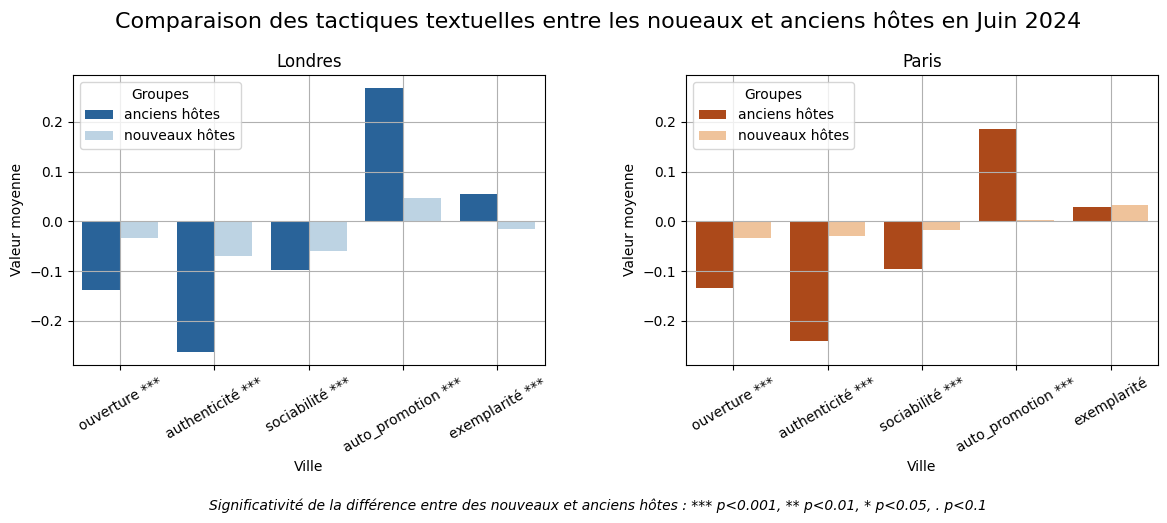

In [25]:

## 2406 london + paris new vs old
import matplotlib.pyplot as plt
importlib.reload(desc_new_old)
from utils.desc_new_old import ttest_new_old

 
order_tactics = ["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]

# ---plot data---    
df_plot=ttest_new_old(df, times=["2406"], in_paris=[0,1], vars=order_tactics)

# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 2 # 每组柱子的数量
london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
paris_colors  = orange_cmap(np.linspace(0.3, 0.8, n))

colors = (
    list(london_colors) +
    list(paris_colors)
)


## ---layout 2facets----
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(14, 5)) 
gs = gridspec.GridSpec(1, 2, figure=fig, hspace=0.5, wspace=0.3)# 1行2列

axes = []
# 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:1])
ax2 = fig.add_subplot(gs[0, 1:2], sharey=ax1)#**
axes.extend([ax1, ax2])


# ---plot---
for i, p in enumerate(df_plot['in_paris'].unique()):
    ax=axes[i]
    
    sub=df_plot[df_plot['in_paris']==p]
    if p==1:
        palette=dict(zip(sub['is_new_host'], paris_colors))
    else :
        palette=dict(zip(sub['is_new_host'], london_colors))
   
    sns.barplot(
        data=sub,   
        x='variable',
        y="mean",
        hue="is_new_host",
        palette=palette,
        order=order_tactics,
        ax=ax,
    )    
   
    label_map = (
        sub[['variable', 'sig']]
        .drop_duplicates()
        .set_index('variable')['sig']
    )
    ax.set_xticklabels([
        f"{var} {label_map.get(var, '')}".strip()
        for var in order_tactics
    ])

    ax.set_xlabel("Ville")
    ax.set_ylabel("Valeur moyenne")
    ax.tick_params(axis="x",rotation=30)

    ax.set_title(f"{'Paris' if p==1 else 'Londres'}")
    
    handles, labels = ax.get_legend_handles_labels()
    new_labels = ["anciens hôtes", "nouveaux hôtes"]
    ax.legend(handles, new_labels, title="Groupes")
    
    ax.grid()

## ---legend 2facets----
fig.suptitle(
        # "Effets marginaux des tactiques visuelles entre les groupes",
        "Comparaison des tactiques textuelles entre les noueaux et anciens hôtes en Juin 2024",
        fontsize=16,
        y=1.01
    )

plt.figtext(
    0.5, 0.01,
    "Significativité de la différence entre des nouveaux et anciens hôtes : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=10,
    style="italic",   
)
plt.tight_layout(rect=[0, 0.1, 0.8, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.3)#控制子图到底的距离，给text留出空间
plt.show()

# 新房东ouv, authen, socio显著水平更高，但在auto水平更低？exem无区别
# london的趋势相同

#****ttest属于描述，不解释因果！

In [ ]:
# modeling
import statsmodels.api as sm
import statsmodels.formula.api as smf
y="authenticité"
formula= (f"{y} ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
        "number_of_reviews_ltm + "
        "C(host_is_superhost) +"
        "years_since_host + professional_host + "
        "host_response_rate +  C(host_response_time)+"
        "has_text + lang_en + lang_fr + text_length+"
        "price  + availability_90 + C(room_type) + C(instant_bookable) + "
        "C(time) + in_paris * C(time)*is_new_host"
)

model_new=smf.ols(formula, data=df).fit()
print(model_new.summary())
# qui a contribué au changement de tactique?
# 回答JO 是否主要通过“新房东进入结构变化”起作用？

                            OLS Regression Results                            
Dep. Variable:           authenticité   R-squared:                       0.171
Model:                            OLS   Adj. R-squared:                  0.170
Method:                 Least Squares   F-statistic:                     1770.
Date:                Tue, 14 Apr 2026   Prob (F-statistic):               0.00
Time:                        21:43:09   Log-Likelihood:            -2.6370e+05
No. Observations:              266852   AIC:                         5.275e+05
Df Residuals:                  266820   BIC:                         5.278e+05
Df Model:                          31                                         
Covariance Type:            nonrobust                                         
                                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

In [67]:
from utils import modeling_did
importlib.reload(modeling_did)
from utils.modeling_did import get_ddd_effect_interaction, get_real_cf_effect_data

ddd=get_ddd_effect_interaction(model=model_new, var="is_new_host")
display(ddd)
get_real_cf_effect_data(model=model_new, tactics=['is_new_host'], ddd_df=ddd)
# ttest新老房东差异显著，但是ddd不显著



,variable,coef,se,pval,sig,ci_low,ci_high
0,is_new_host,0.017398,0.01349,0.197138,,-0.009041,0.043838


is_new_host


,time,in_paris,variable,effect_hat,effect_cf,se,pval,sig,ci_low,ci_high
0,2306,0,is_new_host,0.053205,0.053205,0.003441,0.000000e+00,***,0.046460,0.059950
1,2312,0,is_new_host,0.070341,0.070341,0.007362,0.000000e+00,***,0.055912,0.084771
2,2406,0,is_new_host,0.089273,0.089273,0.006965,0.000000e+00,***,0.075622,0.102925
3,2306,1,is_new_host,0.053658,0.053658,0.003199,0.000000e+00,***,0.047388,0.059928
4,2312,1,is_new_host,0.062322,0.062322,0.007586,2.220446e-16,***,0.047453,0.077190
5,2406,1,is_new_host,0.098652,0.081253,0.005495,0.000000e+00,***,0.087882,0.109421


(266852, 126) => (79001, 126)


C:\Users\yeliu\AppData\Local\Temp\ipykernel_19064\3151196857.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([
C:\Users\yeliu\AppData\Local\Temp\ipykernel_19064\3151196857.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([
C:\Users\yeliu\AppData\Local\Temp\ipykernel_19064\3151196857.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 0.8, 1])# [left, bottom, right, top]


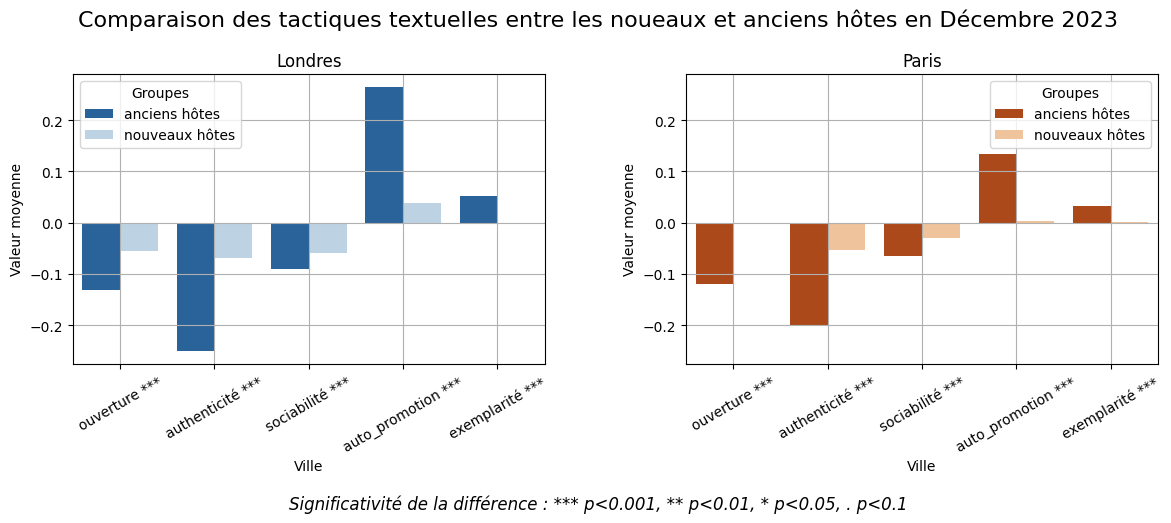

In [26]:
## 2312 london + paris new vs old
import matplotlib.pyplot as plt

# ---plot data---
order_tactics = ["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]
df_plot=ttest_new_old(df, times=["2312"], in_paris=[0,1], vars=order_tactics)

# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 2 # 每组柱子的数量
london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
paris_colors  = orange_cmap(np.linspace(0.3, 0.8, n))

## ---layout 2facets----
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(14, 5)) # sharey=True
gs = gridspec.GridSpec(1, 2, figure=fig, hspace=0.5, wspace=0.3)# 1行2列

axes = []
# 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:1])
ax2 = fig.add_subplot(gs[0, 1:2], sharey=ax1)
axes.extend([ax1, ax2])


# ---plot---
for i, p in enumerate(df_plot['in_paris'].unique()):
    ax=axes[i]
    
    sub=df_plot[df_plot['in_paris']==p]
    if p==1:
        palette=dict(zip(sub['is_new_host'], paris_colors))
    else :
        palette=dict(zip(sub['is_new_host'], london_colors))
   
    sns.barplot(
        data=sub,   # 用 df_long（不是 df_stats）
        x='variable',
        y="mean",
        hue="is_new_host",
        palette=palette,
        order=order_tactics,
        ax=ax,
        
    )
    
    label_map = (
        sub[['variable', 'sig']]
        .drop_duplicates()
        .set_index('variable')['sig']
    )

    ax.set_xticklabels([
        f"{var} {label_map.get(var, '')}".strip()
        for var in order_tactics
    ])

    ax.set_title(f"{'Paris' if p==1 else 'Londres'}")
    ax.set_xlabel("Ville")
    ax.set_ylabel("Valeur moyenne")
    ax.tick_params(axis="x",rotation=30)
    handles, labels = ax.get_legend_handles_labels()
    new_labels = ["anciens hôtes", "nouveaux hôtes"]
    ax.legend(handles, new_labels, title="Groupes")
    ax.grid()

## ---legend 2facets----
fig.suptitle(
    "Comparaison des tactiques textuelles entre les noueaux et anciens hôtes en Décembre 2023",
    fontsize=16,
        y=1.01
    )

plt.figtext(
    0.5, 0.01,
    "Significativité de la différence : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic",   
)
plt.tight_layout(rect=[0, 0.1, 0.8, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.3)#控制子图到底的距离，给text留出空间
plt.show()

# 2312(类似于2406),在两地类似，前三增加，auto减少

In [ ]:

## 2406 : london + paris superhost vs autres
# df['host_is_superhost']=df['host_is_superhost'].apply(lambda x : 1 if x=="t" else 0)
# print(df['host_is_superhost'].value_counts())


(266852, 126) => (112594, 126)


C:\Users\yeliu\AppData\Local\Temp\ipykernel_25528\4025255572.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([
C:\Users\yeliu\AppData\Local\Temp\ipykernel_25528\4025255572.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([
C:\Users\yeliu\AppData\Local\Temp\ipykernel_25528\4025255572.py:91: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 0.8, 1])# [left, bottom, right, top]


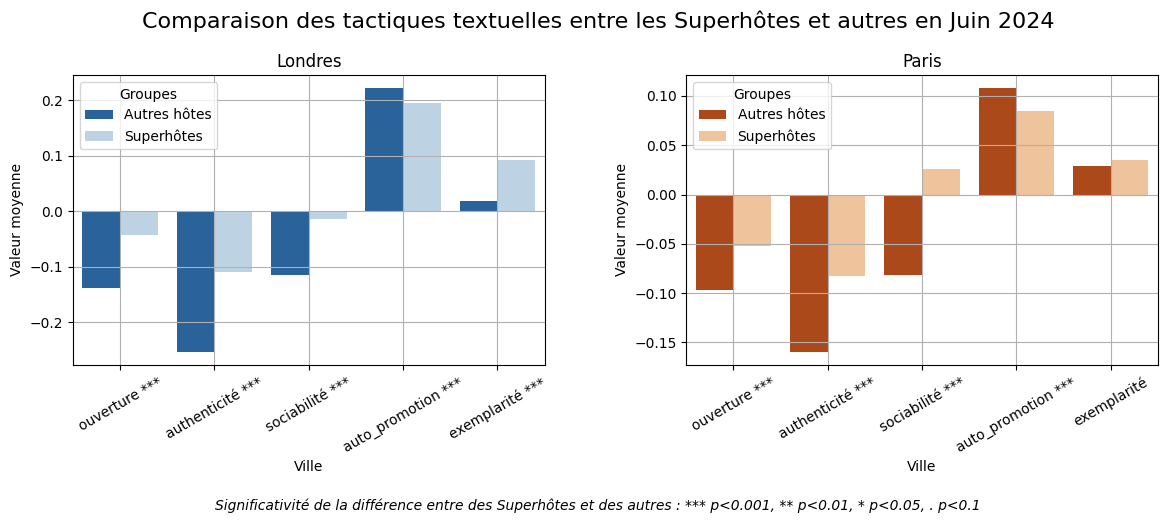

In [74]:
# 2406 : paris + london, superhost vs others:
# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 2 # 每组柱子的数量
london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
paris_colors  = orange_cmap(np.linspace(0.3, 0.8, n))

colors = (
    list(london_colors) +
    list(paris_colors)
)

## ---layout 2facets----
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(14, 5)) # sharey=True
gs = gridspec.GridSpec(1, 2, figure=fig, hspace=0.5, wspace=0.3)# 1行2列

axes = []
# 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:1])
ax2 = fig.add_subplot(gs[0, 1:2])
axes.extend([ax1, ax2])


# ---data---
importlib.reload(desc_new_old)
from utils.desc_new_old import ttest_superhost
order_tactics = ["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]
df_plot=ttest_superhost(df, times=["2406"], in_paris=[0,1], vars=order_tactics)

# ---plot---

subplot_col='in_paris'
hue_col="host_is_superhost"

for i, p in enumerate(df_plot[subplot_col].unique()):#分图
    ax=axes[i]
    sub=df_plot[df_plot[subplot_col]==p]
    # display(sub)
    
    if p==1:
        palette=dict(zip(sub[hue_col].unique(), paris_colors))
    else :
        palette=dict(zip(sub[hue_col].unique(), london_colors))
   
    sns.barplot(
        data=sub,   
        x='variable',
        y="mean",
        hue=hue_col,
        palette=palette,
        order=order_tactics,
        ax=ax
    )   
    
    label_map = (
        sub[['variable', 'sig']]
        .drop_duplicates()
        .set_index('variable')['sig']
    )
    
    ax.set_xticklabels([
        f"{var} {label_map.get(var, '')}".strip()
        for var in order_tactics
    ])

    ax.set_title(f"{'Paris' if p==1 else 'Londres'}")
    ax.set_xlabel("Ville")
    ax.set_ylabel("Valeur moyenne")
    ax.tick_params(axis="x",rotation=30)
    handles, labels = ax.get_legend_handles_labels()
    labels = ["Autres hôtes","Superhôtes"]
    ax.legend(handles, labels, title="Groupes")
    ax.grid()

## ---legend 2facets----
fig.suptitle(
    "Comparaison des tactiques textuelles entre les Superhôtes et autres en Juin 2024",
    fontsize=16,
        y=1.01
    )

plt.figtext(
    0.5, 0.01,
    "Significativité de la différence entre des Superhôtes et des autres : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=10,
    style="italic",   
)
plt.tight_layout(rect=[0, 0.1, 0.8, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.3)#控制子图到底的距离，给text留出空间
plt.show()

(266852, 126) => (62342, 126)
is_new_host  time  in_paris
1            2406  1           28562
                   0           11919
             2312  1           11049
                   0           10812
Name: count, dtype: int64


C:\Users\yeliu\AppData\Local\Temp\ipykernel_25528\3439997225.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([
C:\Users\yeliu\AppData\Local\Temp\ipykernel_25528\3439997225.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([
C:\Users\yeliu\AppData\Local\Temp\ipykernel_25528\3439997225.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 0.8, 1])# [left, bottom, right, top]


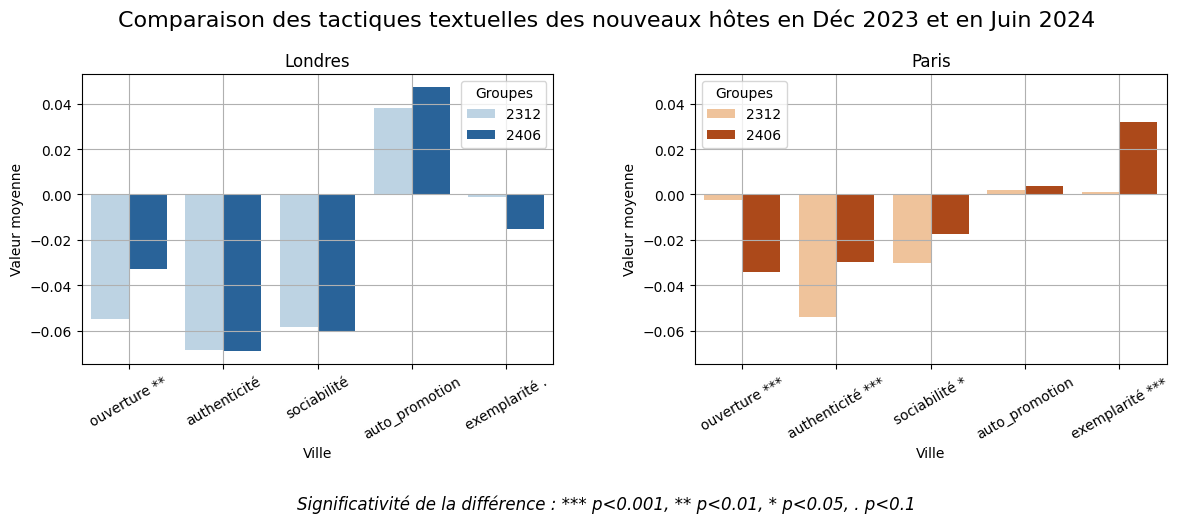

In [ ]:
## NEW paris + london : 2312 vs 2406 [BARPLOT]

# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 2 # 每组柱子的数量
london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
paris_colors  = orange_cmap(np.linspace(0.3, 0.8, n))
# #649BC8
colors = (
    list(london_colors) +
    list(paris_colors)
)


## ---layout 2facets----
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(14, 5)) # sharey=True
gs = gridspec.GridSpec(1, 2, figure=fig, hspace=0.5, wspace=0.3)# 1行2列

axes = []
# 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:1])
ax2 = fig.add_subplot(gs[0, 1:2], sharey=ax1)
axes.extend([ax1, ax2])



# ---plot data---
importlib.reload(desc_new_old)
from utils.desc_new_old import ttest_by_time
order_tactics = ["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]
df_plot=ttest_by_time(df, times=["2312","2406"], in_paris=[0,1],is_new_host=[1], vars=order_tactics)

# ---plot---
for i, p in enumerate(df_plot['in_paris'].unique()):# ***分左右两图
    # print(p)
    ax=axes[i]
    
    sub=df_plot[df_plot['in_paris']==p]
    # display(sub)
    
    if p==1:# hue：分柱子的颜色
        palette=dict(zip(sub['time'].unique(), paris_colors))
    else :
        palette=dict(zip(sub['time'].unique(), london_colors))
        
    sns.barplot(
        data=sub, 
        x='variable',
        y="mean",
        hue="time",# hue
        palette=palette,
        order=order_tactics,
        ax=ax,        
    )
    
    label_map = (
        sub[['variable', 'sig']]
        .drop_duplicates()
        .set_index('variable')['sig']
    )
    ax.set_xticklabels([
        f"{var} {label_map.get(var, '')}".strip()
        for var in order_tactics
    ])

    ax.set_title(f"{'Paris' if p==1 else 'Londres'}")
    ax.set_xlabel("Ville")
    ax.set_ylabel("Valeur moyenne")
    ax.tick_params(axis="x",rotation=30)
    # legend的分组
    handles, labels = ax.get_legend_handles_labels()
    # labels = ["Dec 2023", ""]
    ax.legend(handles, labels, title="Groupes")
    ax.grid()

## ---legend 2facets----
fig.suptitle(
    "Comparaison des tactiques textuelles des nouveaux hôtes en Déc 2023 et en Juin 2024",
    fontsize=16,
    y=1.01
)

plt.figtext(
    0.5, 0.01,
    "Significativité de la différence : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic",   
)
plt.tight_layout(rect=[0, 0.1, 0.8, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.3)#控制子图到底的距离，给text留出空间
plt.show()
#从2312到2406，paris新房东更多使用auth, socio, exem，但是ouv和auto更少
# 但london的新房东没有呈现相同的趋势!!!jo刺激了新房东


(266852, 126) => (62342, 126)
is_new_host  time  in_paris
1            2406  1           28562
                   0           11919
             2312  1           11049
                   0           10812
Name: count, dtype: int64


C:\Users\yeliu\AppData\Local\Temp\ipykernel_25528\2901628447.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 0.8, 1])# [left, bottom, right, top]


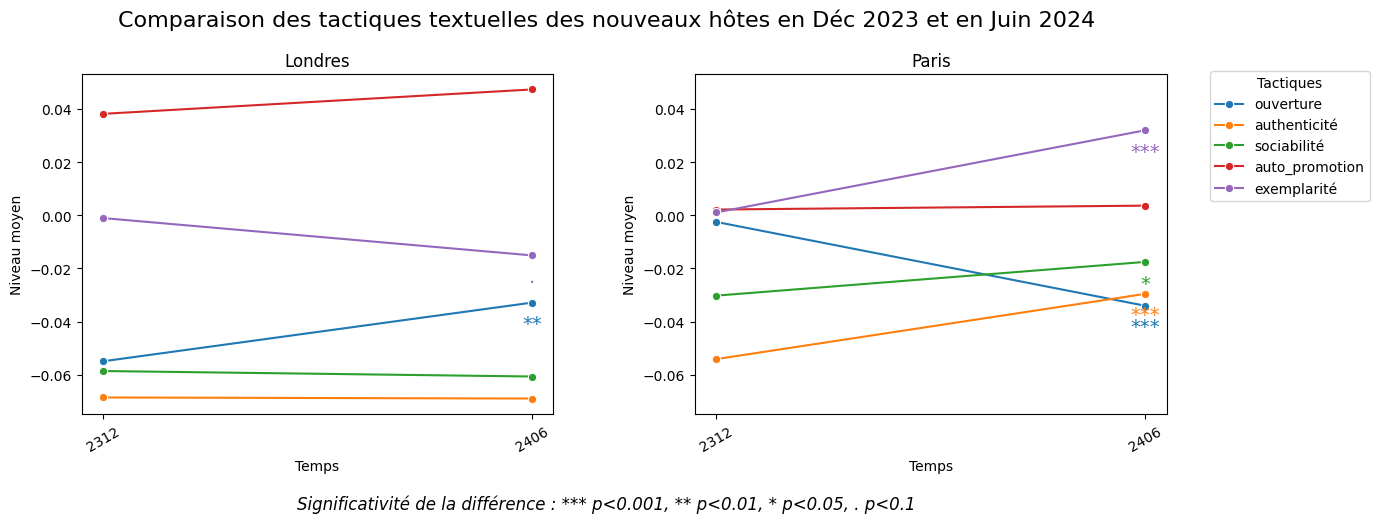

In [ ]:
## NEW paris + london : 2312 vs 2406 [LINEPLOT]

# # ---colors----
palette = {
    "ouverture": "#1f77b4",
    "authenticité": "#ff7f0e",
    "sociabilité": "#2ca02c",
    "auto_promotion": "#d62728",
    "exemplarité": "#9467bd"
}

## ---layout 2facets----
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(14, 5)) # sharey=True
gs = gridspec.GridSpec(1, 2, figure=fig, hspace=0.5, wspace=0.3)# 1行2列

axes = []
# 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:1])
ax2 = fig.add_subplot(gs[0, 1:2], sharey=ax1)
axes.extend([ax1, ax2])


# ---plot data---
importlib.reload(desc_new_old)
from utils.desc_new_old import ttest_by_time
order_tactics = ["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]
df_plot=ttest_by_time(df, times=["2312","2406"], in_paris=[0,1],is_new_host=[1], vars=order_tactics)

# ---plot---
for i, p in enumerate(df_plot['in_paris'].unique()):# ***分左右两图
    # print(p)
    ax=axes[i]
    
    sub=df_plot[df_plot['in_paris']==p]
    # display(sub)
    
    x=list(range(len(sub['time'])))
    # print('axis x :', x)
        
    sns.lineplot(
        data=sub, 
        x='time',
        # x=x,
        y="mean",
        hue="variable",# hue
        marker='o',
        linestyle="-",
        palette=palette,
        # order=order_tactics,
        ax=ax,        
    )
    sub_sig=sub[sub['time']=="2406"]
    # display(sub_sig)
    for _, row in sub_sig.iterrows():
        ax.text(row['time'], row["mean"] - 0.01, row["sig"],
                ha='center', fontsize=14, color=palette[row['variable']])

    ax.set_title(f"{'Paris' if p==1 else 'Londres'}")
    ax.set_xlabel("Temps")
    ax.set_ylabel("Niveau moyen")
    ax.tick_params(axis="x",rotation=30)
    
    if ax.legend():
        ax.get_legend().remove()
    

## ---legend 2facets----
fig.suptitle(
    "Comparaison des tactiques textuelles des nouveaux hôtes en Déc 2023 et en Juin 2024",
    fontsize=16,
    y=1.01
)

plt.figtext(
    0.5, 0.01,
    "Significativité de la différence : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic",   
)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Tactiques", loc="upper right", bbox_to_anchor=(1.05, 0.9))

plt.tight_layout(rect=[0, 0.1, 0.8, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.2)#控制子图到底的距离，给text留出空间
plt.show()

# london的新房东除了ouv上上，没有显著改变策略，
# 但是paris的大多策略都发生了显著变化:
# auth, socio上升，ouv下降，auto没有显著变化，exem上升


(266852, 126) => (129253, 126)
is_new_host  time  in_paris
0            2406  0           37937
                   1           34176
             2312  0           32360
                   1           24780
Name: count, dtype: int64


,time,in_paris,variable,t_stat,p_value,sig,is_new_host,mean,label
0,2312,0,ouverture,1.546633,0.121956,,0,-0.130710,ouverture
0,2406,0,ouverture,1.546633,0.121956,,0,-0.138921,ouverture
0,2312,0,authenticité,2.014196,0.043993,*,0,-0.250389,authenticité *
0,2406,0,authenticité,2.014196,0.043993,*,0,-0.262354,authenticité *
0,2312,0,sociabilité,1.190574,0.233825,,0,-0.090225,sociabilité
0,2406,0,sociabilité,1.190574,0.233825,,0,-0.096956,sociabilité
0,2312,0,auto_promotion,-0.551195,0.581502,,0,0.264328,auto_promotion
0,2406,0,auto_promotion,-0.551195,0.581502,,0,0.267661,auto_promotion
0,2312,0,exemplarité,-0.728644,0.466222,,0,0.050942,exemplarité
0,2406,0,exemplarité,-0.728644,0.466222,,0,0.054928,exemplarité


,time,in_paris,variable,t_stat,p_value,sig,is_new_host,mean,label
0,2312,1,ouverture,2.581436,9.841665e-03,**,0,-0.119163,ouverture **
0,2406,1,ouverture,2.581436,9.841665e-03,**,0,-0.133475,ouverture **
0,2312,1,authenticité,6.567619,5.158853e-11,***,0,-0.201088,authenticité ***
0,2406,1,authenticité,6.567619,5.158853e-11,***,0,-0.240384,authenticité ***
0,2312,1,sociabilité,5.547168,2.917046e-08,***,0,-0.064347,sociabilité ***
0,2406,1,sociabilité,5.547168,2.917046e-08,***,0,-0.096182,sociabilité ***
0,2312,1,auto_promotion,-9.075568,1.168055e-19,***,0,0.134466,auto_promotion ***
0,2406,1,auto_promotion,-9.075568,1.168055e-19,***,0,0.186465,auto_promotion ***
0,2312,1,exemplarité,0.804076,4.213569e-01,,0,0.032999,exemplarité
0,2406,1,exemplarité,0.804076,4.213569e-01,,0,0.028441,exemplarité


C:\Users\yeliu\AppData\Local\Temp\ipykernel_25528\2413148656.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 0.8, 1])# [left, bottom, right, top]


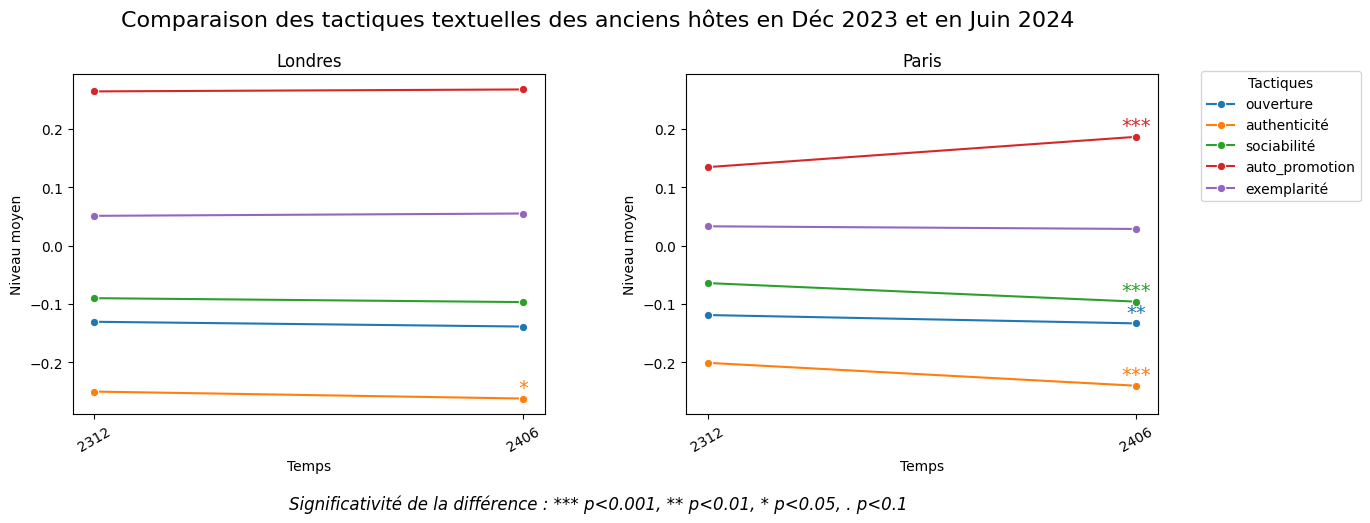

In [82]:
## OLD paris + london : 2312 vs 2406 [LINEPLOT]
# # ---colors----
palette = {
    "ouverture": "#1f77b4",
    "authenticité": "#ff7f0e",
    "sociabilité": "#2ca02c",
    "auto_promotion": "#d62728",
    "exemplarité": "#9467bd"
}

## ---layout 2facets----
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(14, 5)) # sharey=True
gs = gridspec.GridSpec(1, 2, figure=fig, hspace=0.5, wspace=0.3)# 1行2列

axes = []
# 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:1])
ax2 = fig.add_subplot(gs[0, 1:2], sharey=ax1)
axes.extend([ax1, ax2])


# ---plot data---
importlib.reload(desc_new_old)
from utils.desc_new_old import ttest_by_time
order_tactics = ["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]
df_plot=ttest_by_time(df, times=["2312","2406"], in_paris=[0,1],is_new_host=[0], vars=order_tactics)


# ---plot---
for i, p in enumerate(df_plot['in_paris'].unique()):# ***分左右两图
    # print(p)
    ax=axes[i]
    
    sub=df_plot[df_plot['in_paris']==p]
    display(sub)
    
    x=list(range(len(sub['time'])))
    # print('axis x :', x)
        
    sns.lineplot(
        data=sub, 
        x='time',
        # x=x,
        y="mean",
        hue="variable",# hue
        marker='o',
        linestyle="-",
        # style="variable",
        palette=palette,
        # order=order_tactics,
        ax=ax,        
    )
    sub_sig=sub[sub['time']=="2406"]
    # display(sub_sig)
    for _, row in sub_sig.iterrows():
        ax.text(row['time'], row["mean"] + 0.01, row["sig"],
                ha='center', fontsize=14, color=palette[row['variable']])

    ax.set_title(f"{'Paris' if p==1 else 'Londres'}")
    ax.set_xlabel("Temps")
    ax.set_ylabel("Niveau moyen")
    ax.tick_params(axis="x",rotation=30)
    
    if ax.legend():
        ax.get_legend().remove()
    

## ---legend 2facets----
fig.suptitle(
    "Comparaison des tactiques textuelles des anciens hôtes en Déc 2023 et en Juin 2024",
    fontsize=16,
    y=1.01
)

plt.figtext(
    0.5, 0.01,
    "Significativité de la différence : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic",   
)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Tactiques", loc="upper right", bbox_to_anchor=(1.05, 0.9))

plt.tight_layout(rect=[0, 0.1, 0.8, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.2)#控制子图到底的距离，给text留出空间
plt.show()

In [83]:
# paris: new + old, tactics [LINEPLOT]
 
importlib.reload(desc_new_old)
from utils.desc_new_old import ttest_by_time
order_tactics = ["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]
df_plot=ttest_by_time(df, times=["2312","2406"], in_paris=[1],is_new_host=[0,1], vars=order_tactics)
df_plot



(266852, 126) => (98567, 126)
is_new_host  time  in_paris
0            2406  1           34176
1            2406  1           28562
0            2312  1           24780
1            2312  1           11049
Name: count, dtype: int64


,time,in_paris,variable,t_stat,p_value,sig,is_new_host,mean,label
0,2312,1,ouverture,5.533963,3.166305e-08,***,1,-0.002521,ouverture ***
0,2406,1,ouverture,5.533963,3.166305e-08,***,1,-0.034036,ouverture ***
0,2312,1,authenticité,-4.029937,5.599858e-05,***,1,-0.054085,authenticité ***
0,2406,1,authenticité,-4.029937,5.599858e-05,***,1,-0.029554,authenticité ***
0,2312,1,sociabilité,-2.129152,3.325350e-02,*,1,-0.030222,sociabilité *
0,2406,1,sociabilité,-2.129152,3.325350e-02,*,1,-0.017548,sociabilité *
0,2312,1,auto_promotion,-0.241920,8.088449e-01,,1,0.002145,auto_promotion
0,2406,1,auto_promotion,-0.241920,8.088449e-01,,1,0.003604,auto_promotion
0,2312,1,exemplarité,-4.898418,9.723848e-07,***,1,0.001056,exemplarité ***
0,2406,1,exemplarité,-4.898418,9.723848e-07,***,1,0.031944,exemplarité ***


(266852, 126) => (191595, 126)
is_new_host  time  in_paris
0            2406  0           37937
                   1           34176
             2312  0           32360
1            2406  1           28562
0            2312  1           24780
1            2406  0           11919
             2312  1           11049
                   0           10812
Name: count, dtype: int64


,time,in_paris,variable,t_stat,p_value,sig,is_new_host,mean,change
0,2312,1,ouverture,5.533963,3.166305e-08,***,1,-0.002521,-
0,2406,1,ouverture,5.533963,3.166305e-08,***,1,-0.034036,-
0,2312,1,authenticité,-4.029937,5.599858e-05,***,1,-0.054085,+
0,2406,1,authenticité,-4.029937,5.599858e-05,***,1,-0.029554,+
0,2312,1,sociabilité,-2.129152,3.325350e-02,*,1,-0.030222,+
0,2406,1,sociabilité,-2.129152,3.325350e-02,*,1,-0.017548,+
0,2312,1,auto_promotion,-0.241920,8.088449e-01,,1,0.002145,+
0,2406,1,auto_promotion,-0.241920,8.088449e-01,,1,0.003604,+
0,2312,1,exemplarité,-4.898418,9.723848e-07,***,1,0.001056,+
0,2406,1,exemplarité,-4.898418,9.723848e-07,***,1,0.031944,+


,time,in_paris,variable,t_stat,p_value,sig,is_new_host,mean,change
0,2312,1,ouverture,2.581436,9.841665e-03,**,0,-0.119163,-
0,2406,1,ouverture,2.581436,9.841665e-03,**,0,-0.133475,-
0,2312,1,authenticité,6.567619,5.158853e-11,***,0,-0.201088,-
0,2406,1,authenticité,6.567619,5.158853e-11,***,0,-0.240384,-
0,2312,1,sociabilité,5.547168,2.917046e-08,***,0,-0.064347,-
0,2406,1,sociabilité,5.547168,2.917046e-08,***,0,-0.096182,-
0,2312,1,auto_promotion,-9.075568,1.168055e-19,***,0,0.134466,+
0,2406,1,auto_promotion,-9.075568,1.168055e-19,***,0,0.186465,+
0,2312,1,exemplarité,0.804076,4.213569e-01,,0,0.032999,-
0,2406,1,exemplarité,0.804076,4.213569e-01,,0,0.028441,-


,time,in_paris,variable,t_stat,p_value,sig,is_new_host,mean,change
0,2312,0,ouverture,-2.769081,0.005626,**,1,-0.054907,+
0,2406,0,ouverture,-2.769081,0.005626,**,1,-0.032854,+
0,2312,0,authenticité,0.048290,0.961486,,1,-0.068509,-
0,2406,0,authenticité,0.048290,0.961486,,1,-0.068915,-
0,2312,0,sociabilité,0.249636,0.802871,,1,-0.058570,-
0,2406,0,sociabilité,0.249636,0.802871,,1,-0.060629,-
0,2312,0,auto_promotion,-1.081306,0.279572,,1,0.038115,+
0,2406,0,auto_promotion,-1.081306,0.279572,,1,0.047285,+
0,2312,0,exemplarité,1.834206,0.066637,.,1,-0.001066,-
0,2406,0,exemplarité,1.834206,0.066637,.,1,-0.015097,-


,time,in_paris,variable,t_stat,p_value,sig,is_new_host,mean,change
0,2312,0,ouverture,1.546633,0.121956,,0,-0.130710,-
0,2406,0,ouverture,1.546633,0.121956,,0,-0.138921,-
0,2312,0,authenticité,2.014196,0.043993,*,0,-0.250389,-
0,2406,0,authenticité,2.014196,0.043993,*,0,-0.262354,-
0,2312,0,sociabilité,1.190574,0.233825,,0,-0.090225,-
0,2406,0,sociabilité,1.190574,0.233825,,0,-0.096956,-
0,2312,0,auto_promotion,-0.551195,0.581502,,0,0.264328,+
0,2406,0,auto_promotion,-0.551195,0.581502,,0,0.267661,+
0,2312,0,exemplarité,-0.728644,0.466222,,0,0.050942,+
0,2406,0,exemplarité,-0.728644,0.466222,,0,0.054928,+


C:\Users\yeliu\AppData\Local\Temp\ipykernel_19064\1843134000.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 0.8, 1])# [left, bottom, right, top]


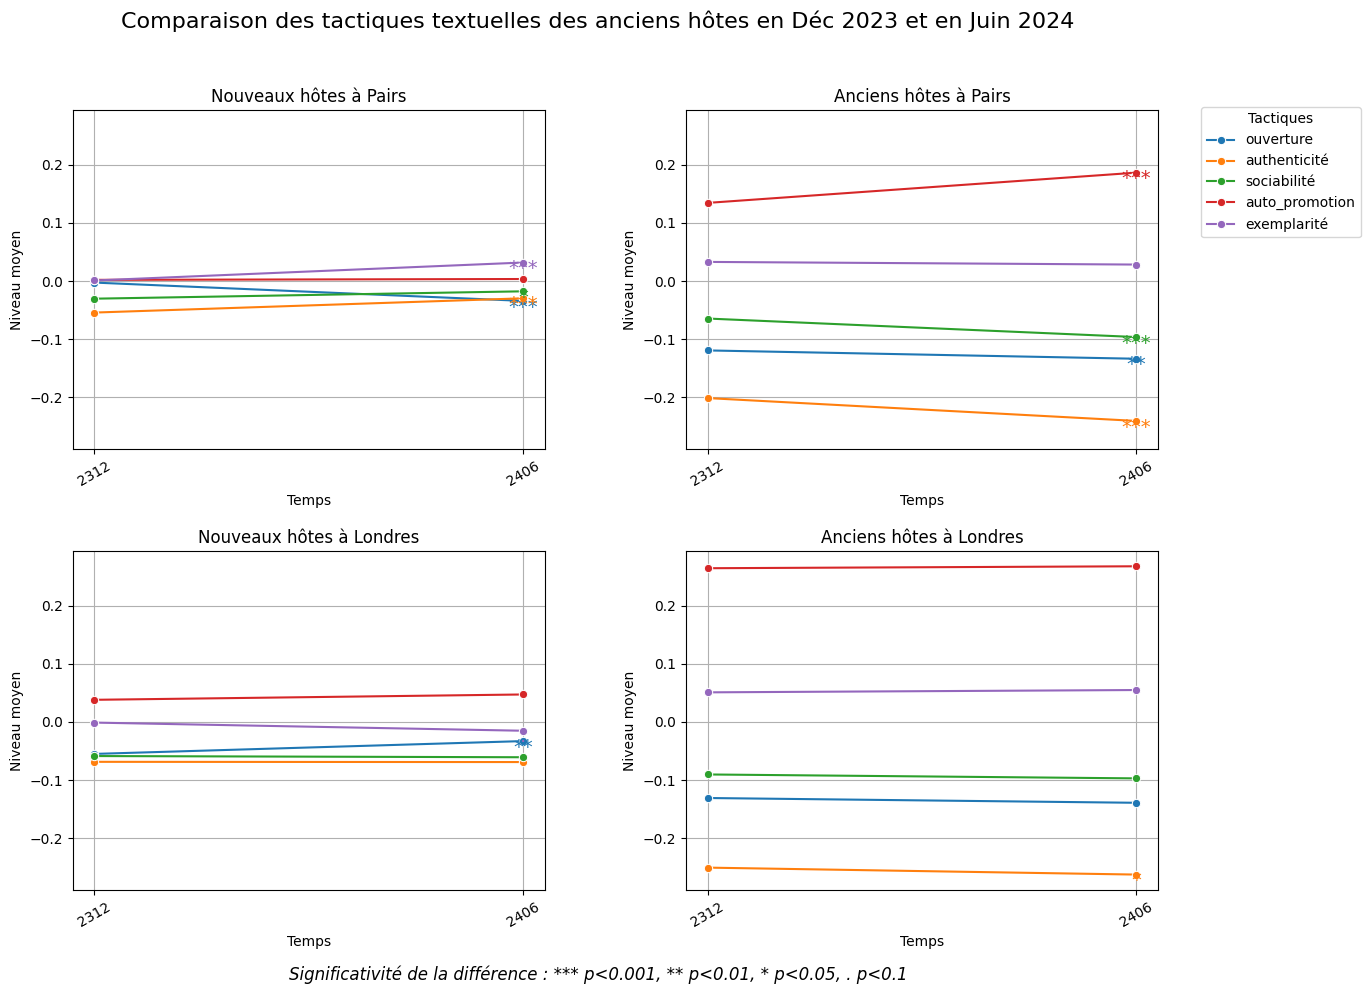

In [22]:

importlib.reload(desc_new_old)
from utils.desc_new_old import ttest_by_time
order_tactics = ["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]
df_plot=ttest_by_time(df, times=["2312","2406"], in_paris=[1, 0],is_new_host=[0,1], vars=order_tactics)
df_plot

# # ---colors----
palette = {
    "ouverture": "#1f77b4",
    "authenticité": "#ff7f0e",
    "sociabilité": "#2ca02c",
    "auto_promotion": "#d62728",
    "exemplarité": "#9467bd"
}

## ---layout 2facets----
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(14, 10)) # sharey=True
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.3, wspace=0.3)# 1行2列

axes = []
# 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:1])
ax2 = fig.add_subplot(gs[0, 1:2], sharey=ax1)
ax3 = fig.add_subplot(gs[1, 0:1], sharey=ax1)
ax4 = fig.add_subplot(gs[1, 1:2], sharey=ax1)
axes.extend([ax1, ax2, ax3, ax4])


# ---plot---
subplot_col1="in_paris"

subplot_col2='is_new_host'
i=0

for p in [1, 0]: #df_plot[subplot_col1].unique(): 
    for n in [1,0]: #df_plot[subplot_col2].unique():# ***分左右两图
        # print(p)
        ax=axes[i]
        
        sub=df_plot[(df_plot[subplot_col1]==p)&(df_plot[subplot_col2]==n)]
        display(sub)
        
        x=list(range(len(sub['time'])))
        # print('axis x :', x)
            
        sns.lineplot(
            data=sub, 
            x='time',
            # x=x,
            y="mean",
            hue="variable",# hue
            marker='o',
            linestyle="-",
            # style="variable",
            palette=palette,
            # order=order_tactics,
            ax=ax,        
        )
        sub_sig=sub[sub['time']=="2406"]
        # display(sub_sig)
        for _, row in sub_sig.iterrows():
            ax.text(row['time'], row["mean"] - 0.02, row["sig"],
                    ha='center', fontsize=14, color=palette[row['variable']])
        city=f"{'Pairs' if p==1 else 'Londres'}"
        is_new_host=f"{'Nouveaux hôtes' if n==1 else 'Anciens hôtes'}"
        ax.set_title(f"{is_new_host} à {city}")
                
        # ax.set_title(f"{subplot_col1}={p} & {subplot_col2}={n}")
        ax.set_xlabel("Temps")
        ax.set_ylabel("Niveau moyen")
        ax.tick_params(axis="x",rotation=30)
        ax.grid()
        if ax.legend():
            ax.get_legend().remove()
        i+=1
        

## ---legend 2facets----
fig.suptitle(
    "Comparaison des tactiques textuelles des anciens hôtes en Déc 2023 et en Juin 2024",
    fontsize=16,
    y=0.98
)

plt.figtext(
    0.5, 0.01,
    "Significativité de la différence : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic",   
)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Tactiques", loc="upper right", bbox_to_anchor=(1.05, 0.89))

plt.tight_layout(rect=[0, 0.1, 0.8, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.1)#控制子图到底的距离，给text留出空间
plt.show()

## 之前的对比（第一个柱状图）：无论london/paris，2406新房东ouv，authen，socio水平老房东高很多
## 老房东更注重策略分布，新房东几乎都集中在平均水平！！！

## paris新房东的策略几乎全部接近平均水平，（可能no text很多?）从2312到2406， ouv减少，auth，socio增多，auto不变，ex增多
## paris旧房东 :ouv, auth, socio减少，auto增多，exem不变

## 对比london新房东：大部分策略变化不显著：仅ouv增多
## london旧房东变化：大部分策略变化不显著：近authe略微减少

## paris变化比london更明显，paris中新老房东变化策略相反！！!


(266852, 126) => (93028, 126)
is_new_host  time  in_paris
0            2406  0           37937
             2312  0           32360
1            2406  0           11919
             2312  0           10812
Name: count, dtype: int64


,time,in_paris,variable,t_stat,p_value,sig,is_new_host,mean,label
0,2312,0,ouverture,-2.769081,0.005626,**,1,-0.054907,ouverture **
0,2406,0,ouverture,-2.769081,0.005626,**,1,-0.032854,ouverture **
0,2312,0,authenticité,0.048290,0.961486,,1,-0.068509,authenticité
0,2406,0,authenticité,0.048290,0.961486,,1,-0.068915,authenticité
0,2312,0,sociabilité,0.249636,0.802871,,1,-0.058570,sociabilité
0,2406,0,sociabilité,0.249636,0.802871,,1,-0.060629,sociabilité
0,2312,0,auto_promotion,-1.081306,0.279572,,1,0.038115,auto_promotion
0,2406,0,auto_promotion,-1.081306,0.279572,,1,0.047285,auto_promotion
0,2312,0,exemplarité,1.834206,0.066637,.,1,-0.001066,exemplarité .
0,2406,0,exemplarité,1.834206,0.066637,.,1,-0.015097,exemplarité .


,time,in_paris,variable,t_stat,p_value,sig,is_new_host,mean,label
0,2312,0,ouverture,1.546633,0.121956,,0,-0.130710,ouverture
0,2406,0,ouverture,1.546633,0.121956,,0,-0.138921,ouverture
0,2312,0,authenticité,2.014196,0.043993,*,0,-0.250389,authenticité *
0,2406,0,authenticité,2.014196,0.043993,*,0,-0.262354,authenticité *
0,2312,0,sociabilité,1.190574,0.233825,,0,-0.090225,sociabilité
0,2406,0,sociabilité,1.190574,0.233825,,0,-0.096956,sociabilité
0,2312,0,auto_promotion,-0.551195,0.581502,,0,0.264328,auto_promotion
0,2406,0,auto_promotion,-0.551195,0.581502,,0,0.267661,auto_promotion
0,2312,0,exemplarité,-0.728644,0.466222,,0,0.050942,exemplarité
0,2406,0,exemplarité,-0.728644,0.466222,,0,0.054928,exemplarité


C:\Users\yeliu\AppData\Local\Temp\ipykernel_25528\2342203044.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 0.8, 1])# [left, bottom, right, top]


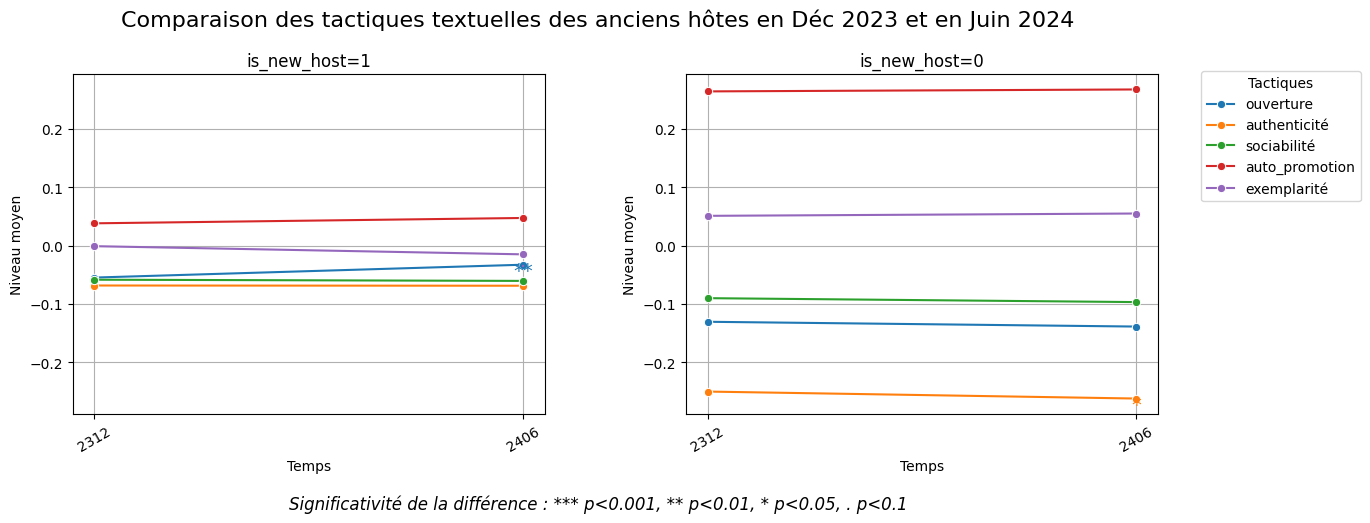

In [ ]:
# 对比 london： new + old, tactics

importlib.reload(desc_new_old)
from utils.desc_new_old import ttest_by_time
order_tactics = ["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]
df_plot=ttest_by_time(df, times=["2312","2406"], in_paris=[0],is_new_host=[0,1], vars=order_tactics)


# # ---colors----
palette = {
    "ouverture": "#1f77b4",
    "authenticité": "#ff7f0e",
    "sociabilité": "#2ca02c",
    "auto_promotion": "#d62728",
    "exemplarité": "#9467bd"
}

## ---layout 2facets----
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(14, 5)) # sharey=True
gs = gridspec.GridSpec(1, 2, figure=fig, hspace=0.5, wspace=0.3)# 1行2列

axes = []
# 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:1])
ax2 = fig.add_subplot(gs[0, 1:2], sharey=ax1)
axes.extend([ax1, ax2])


# ---plot---
subplot_col='is_new_host'
for i, p in enumerate(df_plot[subplot_col].unique()):# ***分左右两图
    # print(p)
    ax=axes[i]
    
    sub=df_plot[df_plot[subplot_col]==p]
    display(sub)
    
    x=list(range(len(sub['time'])))
    # print('axis x :', x)
        
    sns.lineplot(
        data=sub, 
        x='time',
        # x=x,
        y="mean",
        hue="variable",# hue
        marker='o',
        linestyle="-",
        # style="variable",
        palette=palette,
        # order=order_tactics,
        ax=ax,        
    )
    sub_sig=sub[sub['time']=="2406"]
    # display(sub_sig)
    for _, row in sub_sig.iterrows():
        ax.text(row['time'], row["mean"] - 0.02, row["sig"],
                ha='center', fontsize=14, color=palette[row['variable']])

    ax.set_title(f"{subplot_col}={p}")
    ax.set_xlabel("Temps")
    ax.set_ylabel("Niveau moyen")
    ax.tick_params(axis="x",rotation=30)
    ax.grid()
    if ax.legend():
        ax.get_legend().remove()
    

## ---legend 2facets----
fig.suptitle(
    "Comparaison des tactiques textuelles des anciens hôtes en Déc 2023 et en Juin 2024",
    fontsize=16,
    y=1.01
)

plt.figtext(
    0.5, 0.01,
    "Significativité de la différence : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic",   
)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Tactiques", loc="upper right", bbox_to_anchor=(1.05, 0.9))

plt.tight_layout(rect=[0, 0.1, 0.8, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.2)#控制子图到底的距离，给text留出空间
plt.show()

# 新房东接近零水平线，旧房东几乎无变化



In [ ]:
print(df[(df['in_paris']==1)&(df['is_new_host']==1)]['has_text'].value_counts(dropna=False, normalize=True))
print(df[(df['in_paris']==1)&(df['is_new_host']==0)]['has_text'].value_counts(dropna=False, normalize=True))


# 新房东中更多无文本，可能导致更集中于0水平

has_text
0    0.660751
1    0.339249
Name: proportion, dtype: float64
has_text
1    0.504828
0    0.495172
Name: proportion, dtype: float64


In [71]:
#  london + paris : tactic 2312 vs 2406 

# 2312 vs 2406
from scipy import stats

def p_to_sig(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    elif p < 0.1: return '.'
    else: return ''

def ttest_by_time_table(df, times: list=["2312","2406"], in_paris=[0, 1], is_new_host=[1], vars=tactics_bio):
    # ---data---
    df_t=df.copy()        
    df_t = df_t[df_t['time'].isin(times)]
    df_t = df_t[df_t['in_paris'].isin(in_paris)]
    df_t = df_t[df_t['is_new_host'].isin(is_new_host)]
    print(df.shape, '=>', df_t.shape)
    print(df_t[['is_new_host','time', "in_paris"]].value_counts(dropna=False))
    groups_in_paris=df_t['in_paris'].unique()
    groups_new_host=df_t['is_new_host'].unique()
    # print(groups_in_paris)
    
    rows=[]
    for new in groups_new_host: # 统一
        for p in groups_in_paris: #分图 
            for var in vars:
                sub = df_t[(df_t['is_new_host'] == new) & (df_t['in_paris'] == p)]                
                # hue
                early = sub[sub['time'] == "2312"][var].dropna()
                late = sub[sub['time'] == "2406"][var].dropna()
                
                t_stat, p_value = stats.ttest_ind(early, late, equal_var=False)
                sig=p_to_sig(p_value)
                
                row= pd.DataFrame({
                    # "time": ["2312"],
                    'is_new_host':new,
                    "in_paris":[p],
                    "variable":var,
                    'mean_2312':[early.mean()],
                    'mean_2406':[late.mean()],
                    "t_stat": [t_stat],
                    "p_value": [p_value],
                    "sig":[sig],
                    # 'label':f"{var} {sig}"
                })
                # row_late= pd.DataFrame({
                #     "time": ["2406"],
                #     "in_paris":[p],
                #     "variable":var,
                #     "t_stat": [t_stat],
                #     "p_value": [p_value],
                #     "sig":[sig],
                #     'is_new_host':new,
                #     'mean':[late.mean()],
                #     'label':f"{var} {sig}"
                # })
                rows.append(row)
    return pd.concat(rows, axis=0)


tab_new=ttest_by_time_table(df, times=["2312", "2406"], in_paris=[0, 1], is_new_host=[1], vars=tactics_bio)
display(tab_new)

tab_old=ttest_by_time_table(df, times=["2312", "2406"], in_paris=[0, 1], is_new_host=[0], vars=tactics_bio)

display(tab_old)


(266852, 126) => (62342, 126)
is_new_host  time  in_paris
1            2406  1           28562
                   0           11919
             2312  1           11049
                   0           10812
Name: count, dtype: int64


,is_new_host,in_paris,variable,mean_2312,mean_2406,t_stat,p_value,sig
0,1,0,ouverture,-0.054907,-0.032854,-2.769081,5.626104e-03,**
0,1,0,authenticité,-0.068509,-0.068915,0.048290,9.614855e-01,
0,1,0,sociabilité,-0.058570,-0.060629,0.249636,8.028712e-01,
0,1,0,auto_promotion,0.038115,0.047285,-1.081306,2.795725e-01,
0,1,0,exemplarité,-0.001066,-0.015097,1.834206,6.663659e-02,.
0,1,1,ouverture,-0.002521,-0.034036,5.533963,3.166305e-08,***
0,1,1,authenticité,-0.054085,-0.029554,-4.029937,5.599858e-05,***
0,1,1,sociabilité,-0.030222,-0.017548,-2.129152,3.325350e-02,*
0,1,1,auto_promotion,0.002145,0.003604,-0.241920,8.088449e-01,
0,1,1,exemplarité,0.001056,0.031944,-4.898418,9.723848e-07,***


(266852, 126) => (129253, 126)
is_new_host  time  in_paris
0            2406  0           37937
                   1           34176
             2312  0           32360
                   1           24780
Name: count, dtype: int64


,is_new_host,in_paris,variable,mean_2312,mean_2406,t_stat,p_value,sig
0,0,0,ouverture,-0.130710,-0.138921,1.546633,1.219565e-01,
0,0,0,authenticité,-0.250389,-0.262354,2.014196,4.399288e-02,*
0,0,0,sociabilité,-0.090225,-0.096956,1.190574,2.338250e-01,
0,0,0,auto_promotion,0.264328,0.267661,-0.551195,5.815017e-01,
0,0,0,exemplarité,0.050942,0.054928,-0.728644,4.662220e-01,
0,0,1,ouverture,-0.119163,-0.133475,2.581436,9.841665e-03,**
0,0,1,authenticité,-0.201088,-0.240384,6.567619,5.158853e-11,***
0,0,1,sociabilité,-0.064347,-0.096182,5.547168,2.917046e-08,***
0,0,1,auto_promotion,0.134466,0.186465,-9.075568,1.168055e-19,***
0,0,1,exemplarité,0.032999,0.028441,0.804076,4.213569e-01,


(266852, 126) => (129253, 126)
is_new_host  time  in_paris
0            2406  0           37937
                   1           34176
             2312  0           32360
                   1           24780
Name: count, dtype: int64


C:\Users\yeliu\AppData\Local\Temp\ipykernel_25528\673299855.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([
C:\Users\yeliu\AppData\Local\Temp\ipykernel_25528\673299855.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([
C:\Users\yeliu\AppData\Local\Temp\ipykernel_25528\673299855.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 0.8, 1])# [left, bottom, right, top]


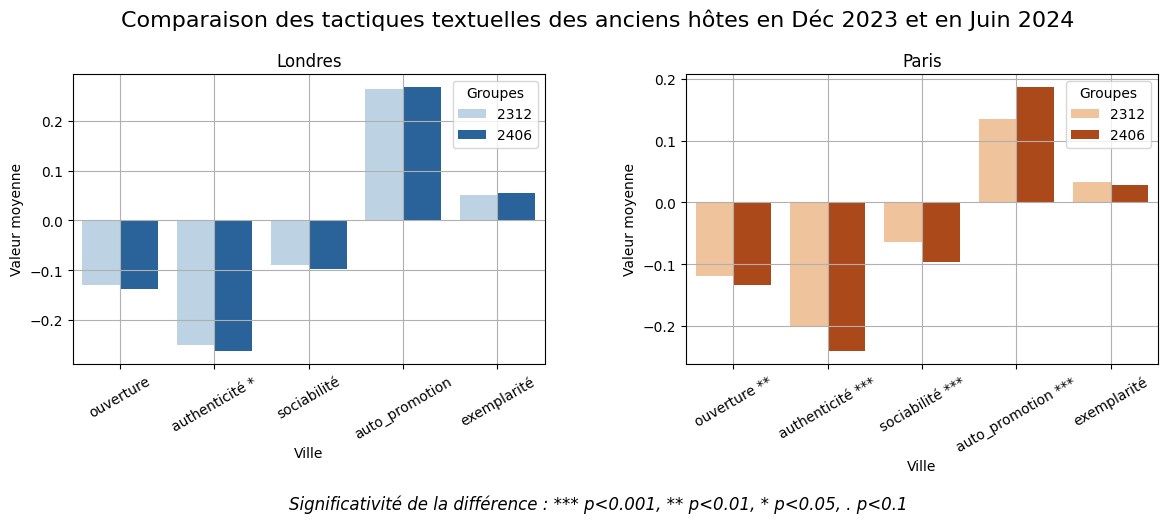

In [48]:
# ## OLD paris + london : 2312 vs 2406
# # ---colors----
# blue_cmap = plt.cm.Blues
# orange_cmap = plt.cm.Oranges
# n = 2 # 每组柱子的数量
# london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
# paris_colors  = orange_cmap(np.linspace(0.3, 0.8, n))
# # #649BC8
# colors = (
#     list(london_colors) +
#     list(paris_colors)
# )

# ## ---layout 2facets----
# import matplotlib.gridspec as gridspec
# fig = plt.figure(figsize=(14, 5)) # sharey=True
# gs = gridspec.GridSpec(1, 2, figure=fig, hspace=0.5, wspace=0.3)# 1行2列

# axes = []
# # 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
# ax1 = fig.add_subplot(gs[0, 0:1])
# ax2 = fig.add_subplot(gs[0, 1:2])
# axes.extend([ax1, ax2])

# # ---plot data---
# importlib.reload(desc_new_old)
# from utils.desc_new_old import ttest_by_time
# order_tactics = ["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]
# df_plot=ttest_by_time(df, times=["2312","2406"], in_paris=[0,1],is_new_host=[0], vars=order_tactics)


# # ---plot---
# for i, p in enumerate(df_plot['in_paris'].unique()):# ***分左右两图
#     # print(p)
#     ax=axes[i]
    
#     sub=df_plot[df_plot['in_paris']==p]
#     # display(sub)
    
#     if p==1:# hue：分柱子的颜色
#         palette=dict(zip(sub['time'].unique(), paris_colors))
#     else :
#         palette=dict(zip(sub['time'].unique(), london_colors))
        
#     sns.barplot(
#         data=sub, 
#         x='variable',
#         y="mean",
#         hue="time",# hue
#         palette=palette,
#         order=order_tactics,
#         ax=ax,        
#     )
    
#     label_map = (
#         sub[['variable', 'sig']]
#         .drop_duplicates()
#         .set_index('variable')['sig']
#     )
#     ax.set_xticklabels([
#         f"{var} {label_map.get(var, '')}".strip()
#         for var in order_tactics
#     ])

#     ax.set_title(f"{'Paris' if p==1 else 'Londres'}")
#     ax.set_xlabel("Ville")
#     ax.set_ylabel("Valeur moyenne")
#     ax.tick_params(axis="x",rotation=30)
#     # legend的分组
#     handles, labels = ax.get_legend_handles_labels()
#     ax.legend(handles, labels, title="Groupes")
#     ax.grid()

# ## ---legend 2facets----
# fig.suptitle(
#     "Comparaison des tactiques textuelles des anciens hôtes en Déc 2023 et en Juin 2024",
#     fontsize=16,
#     y=1.01
# )

# plt.figtext(
#     0.5, 0.01,
#     "Significativité de la différence : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
#     ha="center",
#     fontsize=12,
#     style="italic",   
# )
# plt.tight_layout(rect=[0, 0.1, 0.8, 1])# [left, bottom, right, top]
# plt.subplots_adjust(bottom=0.3)#控制子图到底的距离，给text留出空间
# plt.show()

In [78]:
#老房东是否更加积极地调整他们的策略？？
## PARIS : new + old, 2312 vs 2406
df=df_all.copy()
print(df.shape)
importlib.reload(desc_new_old)
from utils.desc_new_old import ttest_new_old 
df_plot_paris=ttest_new_old(df, times=["2312","2406"], in_paris=[1], vars=tactics_bio)
df_plot_paris=df_plot_paris.sort_values(['is_new_host', "time"])
df_plot_paris

(266852, 126)
(266852, 126) => (98567, 126)


,time,in_paris,variable,t_stat,p_value,sig,is_new_host,mean,label
0,2312,1,ouverture,18.460556,1.204065e-75,***,0,-0.119163,ouverture ***
0,2312,1,authenticité,21.394210,1.022868e-100,***,0,-0.201088,authenticité ***
0,2312,1,sociabilité,5.131289,2.897433e-07,***,0,-0.064347,sociabilité ***
0,2312,1,auto_promotion,-19.837351,5.947470e-87,***,0,0.134466,auto_promotion ***
0,2312,1,exemplarité,-4.817679,1.460343e-06,***,0,0.032999,exemplarité ***
0,2406,1,ouverture,20.624160,3.426978e-94,***,0,-0.133475,ouverture ***
0,2406,1,authenticité,41.635065,0.000000e+00,***,0,-0.240384,authenticité ***
0,2406,1,sociabilité,16.005879,1.513599e-57,***,0,-0.096182,sociabilité ***
0,2406,1,auto_promotion,-36.799807,2.555253e-293,***,0,0.186465,auto_promotion ***
0,2406,1,exemplarité,0.662822,5.074473e-01,,0,0.028441,exemplarité


is_new_host=0


,time,in_paris,variable,t_stat,p_value,sig,is_new_host,mean,label
0,2312,1,ouverture,18.460556,1.204065e-75,***,0,-0.119163,ouverture ***
0,2312,1,authenticité,21.394210,1.022868e-100,***,0,-0.201088,authenticité ***
0,2312,1,sociabilité,5.131289,2.897433e-07,***,0,-0.064347,sociabilité ***
0,2312,1,auto_promotion,-19.837351,5.947470e-87,***,0,0.134466,auto_promotion ***
0,2312,1,exemplarité,-4.817679,1.460343e-06,***,0,0.032999,exemplarité ***
0,2406,1,ouverture,20.624160,3.426978e-94,***,0,-0.133475,ouverture ***
0,2406,1,authenticité,41.635065,0.000000e+00,***,0,-0.240384,authenticité ***
0,2406,1,sociabilité,16.005879,1.513599e-57,***,0,-0.096182,sociabilité ***
0,2406,1,auto_promotion,-36.799807,2.555253e-293,***,0,0.186465,auto_promotion ***
0,2406,1,exemplarité,0.662822,5.074473e-01,,0,0.028441,exemplarité


is_new_host=1


C:\Users\yeliu\AppData\Local\Temp\ipykernel_25528\2322422954.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


,time,in_paris,variable,t_stat,p_value,sig,is_new_host,mean,label
0,2312,1,ouverture,18.460556,1.204065e-75,***,1,-0.002521,ouverture ***
0,2312,1,authenticité,21.394210,1.022868e-100,***,1,-0.054085,authenticité ***
0,2312,1,sociabilité,5.131289,2.897433e-07,***,1,-0.030222,sociabilité ***
0,2312,1,auto_promotion,-19.837351,5.947470e-87,***,1,0.002145,auto_promotion ***
0,2312,1,exemplarité,-4.817679,1.460343e-06,***,1,0.001056,exemplarité ***
0,2406,1,ouverture,20.624160,3.426978e-94,***,1,-0.034036,ouverture ***
0,2406,1,authenticité,41.635065,0.000000e+00,***,1,-0.029554,authenticité ***
0,2406,1,sociabilité,16.005879,1.513599e-57,***,1,-0.017548,sociabilité ***
0,2406,1,auto_promotion,-36.799807,2.555253e-293,***,1,0.003604,auto_promotion ***
0,2406,1,exemplarité,0.662822,5.074473e-01,,1,0.031944,exemplarité


C:\Users\yeliu\AppData\Local\Temp\ipykernel_25528\2322422954.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([
C:\Users\yeliu\AppData\Local\Temp\ipykernel_25528\2322422954.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 0.8, 1])# [left, bottom, right, top]


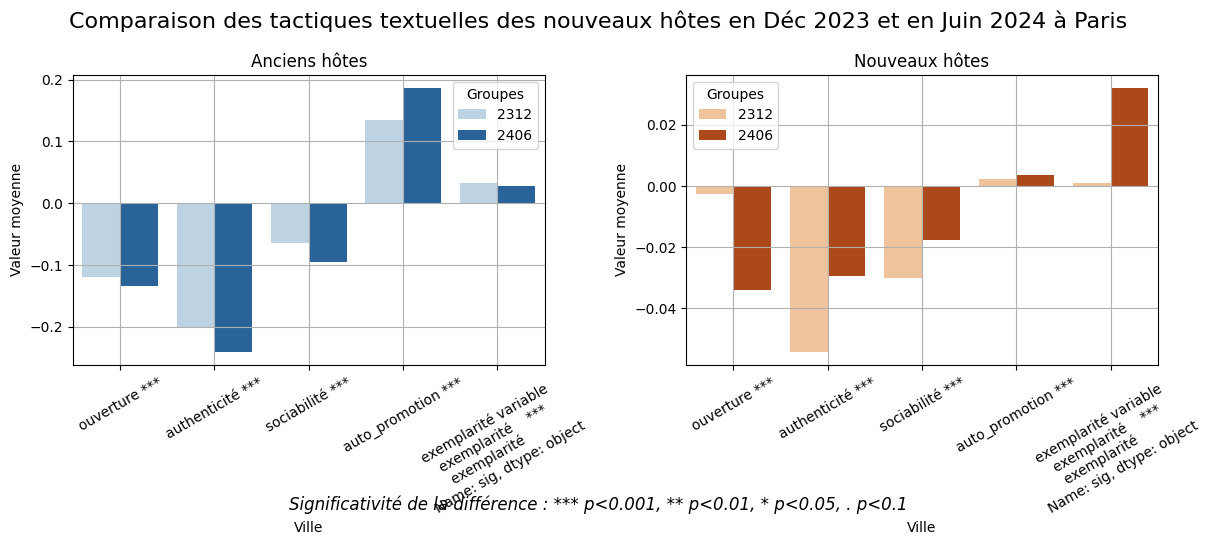

In [80]:
## PARIS : new + old, 2312 vs 2406
import matplotlib.pyplot as plt


order_tactics = ["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]

# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 2 # 每组柱子的数量
london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
paris_colors  = orange_cmap(np.linspace(0.3, 0.8, n))

colors = (
    list(london_colors) +
    list(paris_colors)
)

## ---layout 2facets----
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(14, 5)) # sharey=True
gs = gridspec.GridSpec(1, 2, figure=fig, hspace=0.5, wspace=0.3)# 1行2列

axes = []
# 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:1])
ax2 = fig.add_subplot(gs[0, 1:2])
axes.extend([ax1, ax2])


# ---plot---
df_plot=df_plot_paris.copy()#***
subplot_col="is_new_host"
hue_col="time"

for i, sub_g in enumerate(df_plot[subplot_col].unique()):
    ax=axes[i]
    sub=df_plot[df_plot[subplot_col]==sub_g]
    print(f"{subplot_col}={sub_g}")
    display(sub)
    if sub_g==1:
        palette=dict(zip(sub[hue_col].unique(), paris_colors))
    else :
        palette=dict(zip(sub[hue_col].unique(), london_colors))
   
    sns.barplot(
        data=sub,   
        x='variable',
        y="mean",
        hue=hue_col,
        palette=palette,
        order=order_tactics,
        ax=ax,
    )

    label_map = (
        sub[['variable', 'sig']]
        .drop_duplicates()
        .set_index('variable')['sig']
    )
    ax.set_xticklabels([
        f"{var} {label_map.get(var, '')}".strip()
        for var in order_tactics
    ])

    ax.set_xlabel("Ville")
    ax.set_ylabel("Valeur moyenne")
    ax.tick_params(axis="x",rotation=30)

    ax.set_title(f"{'Nouveaux hôtes' if sub_g==1 else 'Anciens hôtes'}")
    
    handles, labels = ax.get_legend_handles_labels()
    # labels = ["anciens hôtes", "nouveaux hôtes"]
    ax.legend(handles, labels, title="Groupes")
    ax.grid()


## ---legend 2facets----
fig.suptitle(
        # "Effets marginaux des tactiques visuelles entre les groupes",
        "Comparaison des tactiques textuelles des nouveaux hôtes en Déc 2023 et en Juin 2024 à Paris",
        fontsize=16,
        y=1.01
    )

plt.figtext(
    0.5, 0.01,
    "Significativité de la différence : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic",   
)
plt.tight_layout(rect=[0, 0.1, 0.8, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.3)#控制子图到底的距离，给text留出空间
plt.show()

group
nouveaux hôtes(Londres)    5
anciens hôtes(Londres)     5
nouveaux hôtes(Paris)      5
anciens hôtes(Paris)       5
Name: count, dtype: int64


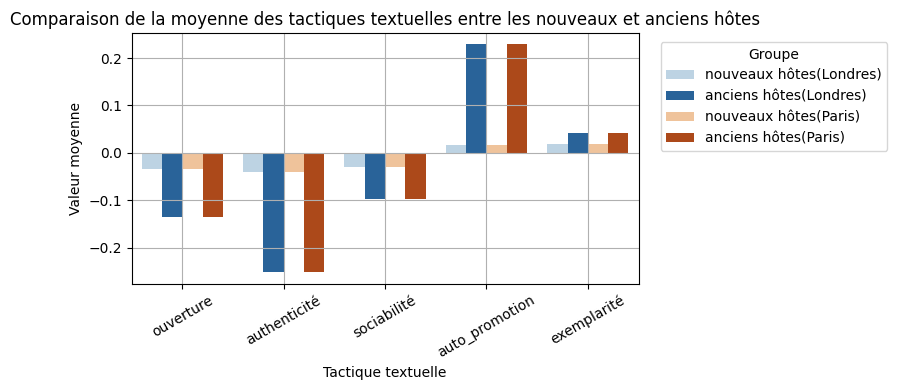

In [88]:
order_tactics = ["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]
df_plot['group'] = df_plot.apply(
    lambda x: f"{'nouveaux hôtes' if x['is_new_host']==1 else 'anciens hôtes'}"
        f"{'(Paris)' if x['in_paris']==1 else '(Londres)'}"
    ,axis=1
)
print(df_plot['group'].value_counts(dropna=False))

# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 2  # 每组数量
london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
paris_colors  = orange_cmap(np.linspace(0.3, 0.8, n))

colors = (
    list(london_colors) +
    list(paris_colors)
)

groups=df_plot['group'].unique()
palette={k: v for k, v in zip (groups, colors)}



fig, ax=plt.subplots(figsize=(6,4))

sns.barplot(
    data=df_plot,   # 用 df_long（不是 df_stats）
    x="variable",
    y="mean",
    hue="group",
    palette=palette,
    order=order_tactics,
    # errorbar="sd",
    ax=ax
)


ax.set_title("Comparaison de la moyenne des tactiques textuelles entre les nouveaux et anciens hôtes")
ax.set_xlabel("Tactique textuelle")
ax.set_ylabel("Valeur moyenne")
ax.tick_params(axis="x",rotation=30)
ax.get_legend().remove()

handles, labels=ax.get_legend_handles_labels()
fig.legend(handles, labels, title="Groupe",  loc="upper left", bbox_to_anchor=(1, 0.9))
ax.grid()
plt.tight_layout(rect=[0, 0, 1, 1])


ouverture
authenticité
sociabilité
auto_promotion
exemplarité


C:\Users\yeliu\AppData\Local\Temp\ipykernel_26240\2060331927.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0, 0.9,1])


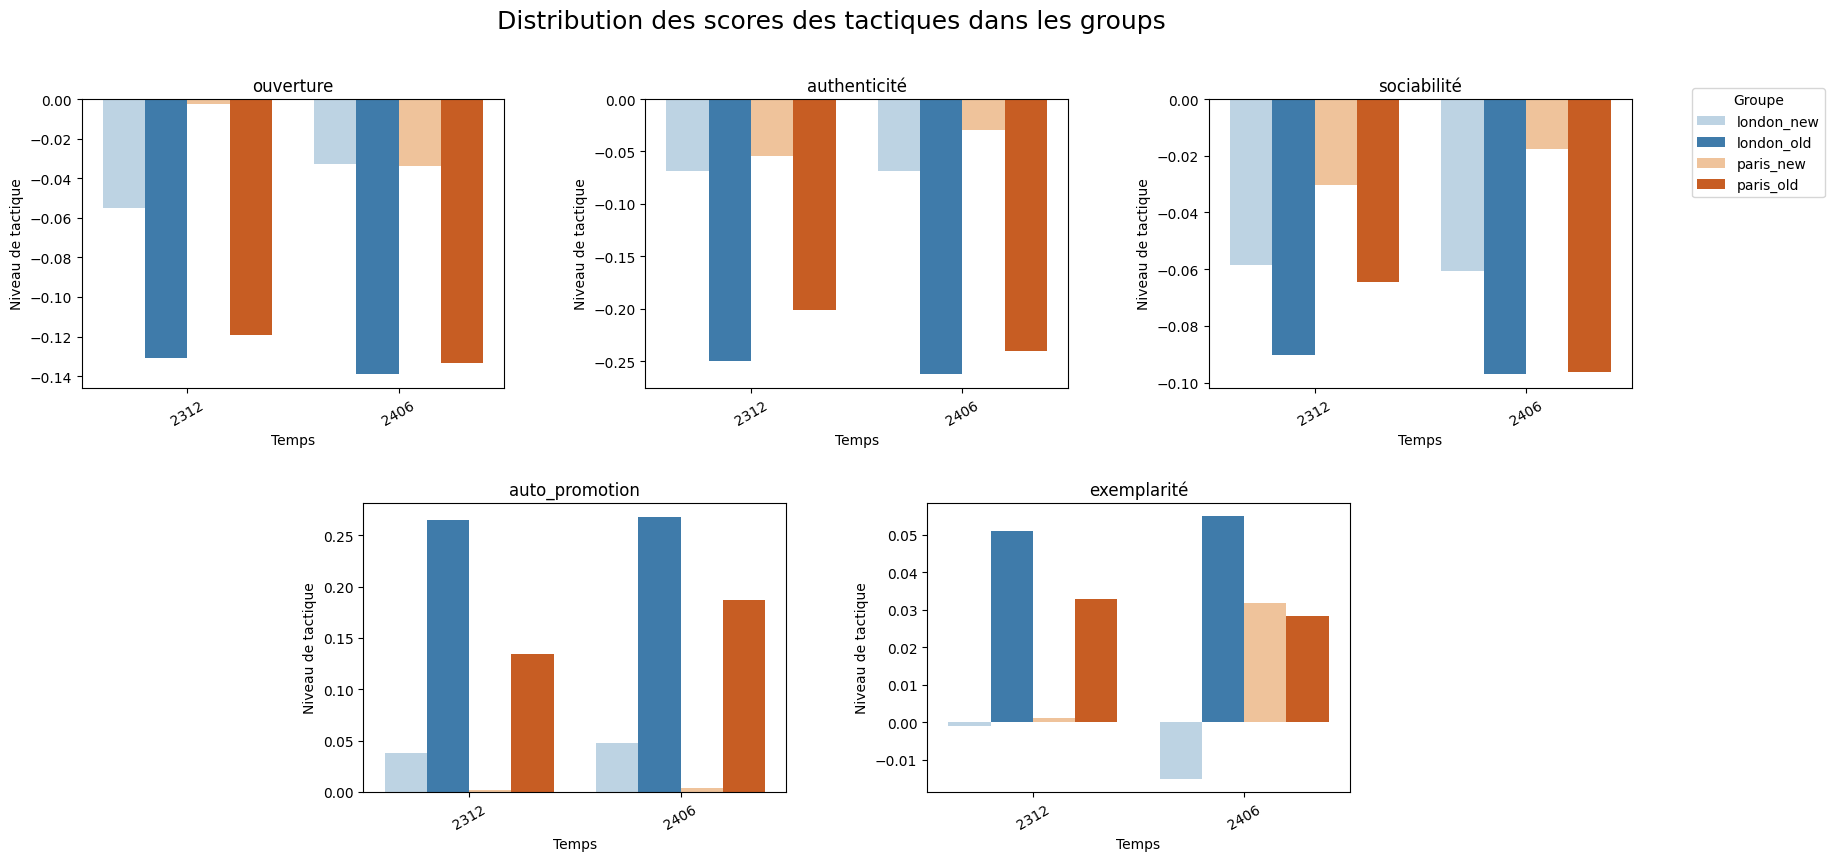

In [42]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

## ---subplot layout---
fig = plt.figure(figsize=(20,9))
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=1)
axes = []
# 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
axes.extend([ax1, ax2, ax3])

# 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
ax4 = fig.add_subplot(gs[1, 1:3])
ax5 = fig.add_subplot(gs[1, 3:5])
axes.extend([ax4, ax5])

# ---data---
# var="authenticité"
# agg=df_plot.groupby(["time","group_pn",'is_new_host'])[var].mean().reset_index()
# agg.rename(columns={f"{var}":"value"}, inplace=True)
# print(agg)


# ---colors----
blue_cmap=plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 2  # 每组数量
london_colors = blue_cmap(np.linspace(0.3, 0.7, n))
paris_colors  = orange_cmap(np.linspace(0.3, 0.7, n))

colors = (
    list(london_colors) +
    list(paris_colors)
)
# groups=df_plot['group_pn'].unique()
# palette={k: v for k, v in zip (groups, colors)}


# ---plot---
# df_plot=sub_df.copy()
for i, var in enumerate(tactics_bio):
    print(var)
    ax=axes[i]
    agg=df_plot.groupby(["time","group_pn",'is_new_host'])[var].mean().reset_index()
    agg.rename(columns={f"{var}":"value"}, inplace=True)

    sns.barplot(
        data=agg,
        x='time',
        y="value",
        hue="group_pn",
        # palette=palette,
        ax=ax
    )
    ax.set_title(var)
    ax.set_xlabel("Temps")
    ax.set_ylabel("Niveau de tactique")
    ax.tick_params(axis="x", rotation=30)
    ax.get_legend().remove()
    
    
fig.suptitle(
        "Distribution des scores des tactiques dans les groups",
        fontsize=18,
        y=0.98
    )
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, title="Groupe", loc="upper right", bbox_to_anchor=(1, 0.9))
plt.tight_layout(rect=[0,0, 0.9,1])
plt.show()
    
    



In [ ]:
import matplotlib.gridspec as gridspec


## ---subplot layout---
fig = plt.figure(figsize=(20,9))
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=1)
axes = []
# 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
axes.extend([ax1, ax2, ax3])

# 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
ax4 = fig.add_subplot(gs[1, 1:3])
ax5 = fig.add_subplot(gs[1, 3:5])
axes.extend([ax4, ax5])


# ---colors---
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 3  # 每组数量
london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
paris_colors  = orange_cmap(np.linspace(0.3, 0.8, n))

colors = (
    list(london_colors) +
    list(paris_colors)
)
# palette={k: v for k, v in zip (groups, colors)}



In [ ]:
# exemple de 2406
df_2406=df[df['time']==2406]
print(df_2406.shape)
print(df_2406[['time','in_paris','new_in_2406']].value_counts(dropna=False))


(112594, 127)
time  in_paris  new_in_2406
2406  0         0              37937
      1         0              34176
                1              28562
      0         1              11919
Name: count, dtype: int64


In [32]:
from utils import preprocess_listings
importlib.reload(preprocess_listings)
from utils.preprocess_listings import group_mean_table_ttest
 
tactics_bio = [
    "ouverture",
    "authenticité",
    "sociabilité",
    "auto_promotion",
    "exemplarité",
]
tactic_pic= [
    "host_picture_type",
    "is_smiling"
]

#  --- num---
vars_ctrl_num=[
    'booking_rate_l90d',
    "review_scores_rating", "has_rating", "number_of_reviews_ltm",
    'professional_host',
    "host_response_rate",
    "price","availability_90", 
    "years_since_host",
    "text_length",
]

# ---cat---
vars_ctrl_cat=[
    # cat
    "host_identity_verified",
    'host_is_superhost',
    'host_response_time',
    'room_type',"instant_bookable",    
    "has_text", "lang_en","lang_fr",    
    # "age_class","gender",
]


##
df_stats=df_2406.copy()
cols_to_check=vars_ctrl_num +tactics_bio

group_mean_table_ttest(df_stats, cols_to_check, group_col='new_in_2406',        
                    save=False, output_folder="mod_results", filename_noext=None)

#新进入，但不是有经验的房东



NameError: name 'df_2406' is not defined

In [71]:
agg=df_2406.groupby(['in_paris', 'new_in_2406'])[tactics_bio].mean().reset_index()
display(agg)

agg_long=agg.melt(
    id_vars=['in_paris','new_in_2406'],
    value_vars=tactics_bio,
    var_name='variable',
    value_name='value'
)
agg_long

,in_paris,new_in_2406,ouverture,authenticité,sociabilité,auto_promotion,exemplarité
0,0,0,-0.138921,-0.262354,-0.096956,0.267661,0.054928
1,0,1,-0.032854,-0.068915,-0.060629,0.047285,-0.015097
2,1,0,-0.133475,-0.240384,-0.096182,0.186465,0.028441
3,1,1,-0.034036,-0.029554,-0.017548,0.003604,0.031944


,in_paris,new_in_2406,variable,value
0,0,0,ouverture,-0.138921
1,0,1,ouverture,-0.032854
2,1,0,ouverture,-0.133475
3,1,1,ouverture,-0.034036
4,0,0,authenticité,-0.262354
5,0,1,authenticité,-0.068915
6,1,0,authenticité,-0.240384
7,1,1,authenticité,-0.029554
8,0,0,sociabilité,-0.096956
9,0,1,sociabilité,-0.060629


In [94]:
sub=agg_long[agg_long['variable']=='authenticité']
sub

,in_paris,new_in_2406,variable,value
4,0,0,authenticité,-0.262354
5,0,1,authenticité,-0.068915
6,1,0,authenticité,-0.240384
7,1,1,authenticité,-0.029554


Text(0.5, 1.0, 'authenticité')

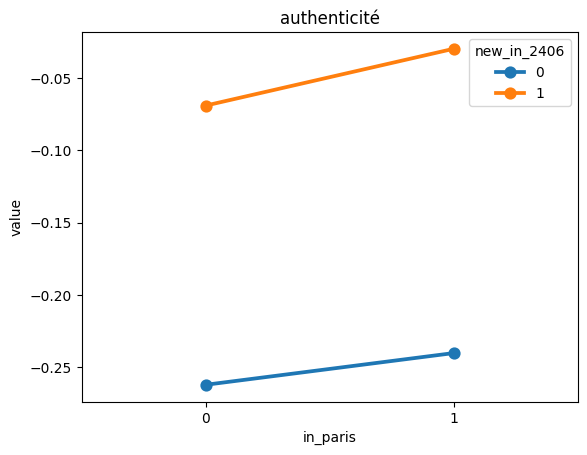

In [97]:
sns.pointplot(
    data=sub,
    x="in_paris",
    y="value",
    hue="new_in_2406",
    errorbar=("ci", 95),
)
plt.title('authenticité')


<Axes: xlabel='in_paris', ylabel='value'>

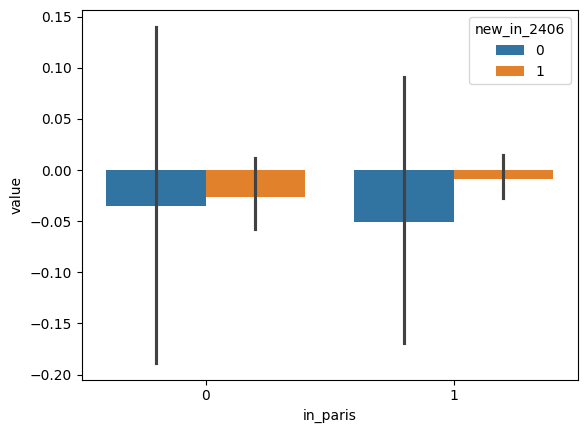

In [ ]:

sns.barplot(
    data=agg_long,
    x="in_paris",
    y="value",
    hue="new_in_2406",
)
plt.xlabel()

0 ouverture


,in_paris,new_in_2406,variable,value
0,0,0,ouverture,-0.138921
1,0,1,ouverture,-0.032854
2,1,0,ouverture,-0.133475
3,1,1,ouverture,-0.034036


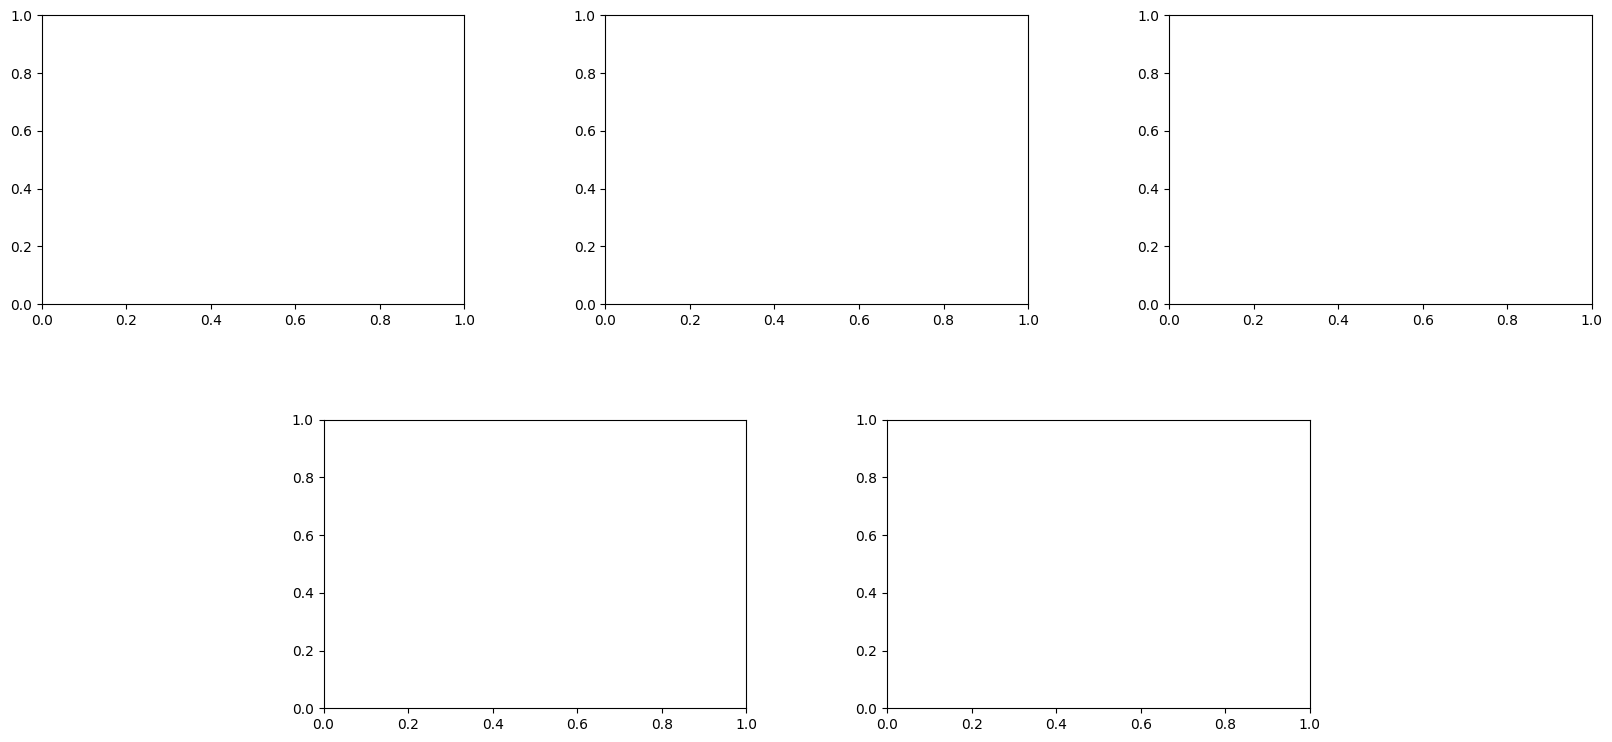

In [83]:
import matplotlib.gridspec as gridspec


# -------------------layout-------------------
# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(20,9))
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=1)

axes = []
# 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
axes.extend([ax1, ax2, ax3])

# 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
ax4 = fig.add_subplot(gs[1, 1:3])
ax5 = fig.add_subplot(gs[1, 3:5])
axes.extend([ax4, ax5])

# 确保 tactics_vars 长度为 5（或小于等于 len(axes)）
n_to_plot = min(len(tactics_bio), len(axes))


df_plot=agg_long.copy()

for i, var in enumerate(tactics_bio):
    print(i, var)
    sub=df_plot[df_plot['variable']==var]
    display(sub)
    
    # ax.plot(
    #     sub['']
    # )
    # sns.barplot(
    #     data=agg_long,
    #     x="in_paris",
    #     y="value",
    #     hue="new_in_2406",
    #     ax=axes[i],
    #     label=f"{'nouveaux entrant' if new_in_2406==1 else 0}"
    # )
    # axes[i].legend().remove()
    break


# handles,labels=axes[0].get_legend_handels_labels()

# sns.catplot(
#     data=agg_long,
#     kind="bar",
#     x="in_paris",
#     y="value",
#     hue="new_in_2406",
#     col="variable",
#     ax=ax,
#     # palette=["tab:blue","tab:orange"]
#     palette=[london_colors[2], paris_colors[2]]
# )